In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub
path = kagglehub.dataset_download("venky73/spam-mails-dataset")

Using Colab cache for faster access to the 'spam-mails-dataset' dataset.


In [3]:
print(path)
os.listdir(path)

/kaggle/input/spam-mails-dataset


['spam_ham_dataset.csv']

In [4]:
import pandas as pd
df = pd.read_csv(os.path.join(path, "spam_ham_dataset.csv"))

In [5]:
df.info()
print(f"duplicate sum : {df.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB
duplicate sum : 0


In [6]:
df['label_num'].value_counts()

,count
label_num,
0,3672
1,1499


In [70]:
df['len'] = df['text'].apply(lambda x : len(x))

In [71]:
print("Spam emails")
df[df['label_num'] == 1]['len'].describe()

Spam emails


,len
count,1499.000000
mean,1223.256171
std,1825.986210
min,11.000000
25%,283.000000
50%,576.000000
75%,1253.500000
max,22073.000000


In [9]:
print("Ham emails")
df[df['label_num'] == 0]['len'].describe()


Ham emails


,len
count,3672.000000
mean,977.008170
std,1382.827493
min,18.000000
25%,231.750000
50%,530.000000
75%,1227.250000
max,32258.000000


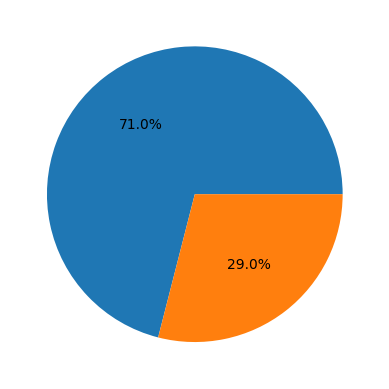

,Unnamed: 0,label,text,label_num,len
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0,327
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,97
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,2524
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1,414
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0,336


In [72]:
plt.pie(df['label'].value_counts(), autopct='%1.1f%%')
plt.show()
df.head()

In [73]:
df.drop(columns=['label'], inplace=True)

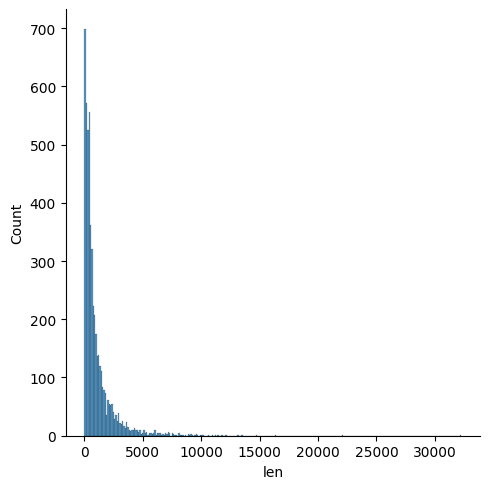

In [74]:
sns.displot(df['len'])


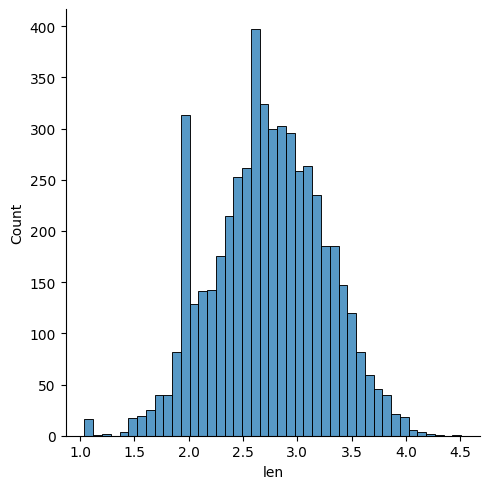

In [75]:
df['len'] = np.log10(df['len'])
sns.displot(df['len'])


In [76]:
df.head(5)

,Unnamed: 0,text,label_num,len
0,605,Subject: enron methanol ; meter # : 988291\r\n...,0,2.514548
1,2349,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,1.986772
2,3624,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,3.402089
3,4685,"Subject: photoshop , windows , office . cheap ...",1,2.617000
4,2030,Subject: re : indian springs\r\nthis deal is t...,0,2.526339


In [77]:
def remove_subject(text):
    if text.startswith("subject:"):
        return text[8:]
    else:
        return text

In [78]:
df['text'] = df['text'].apply(lambda x : x.lower())
df['text'] = df['text'].apply(lambda x : remove_subject(x))
df.head()

,Unnamed: 0,text,label_num,len
0,605,enron methanol ; meter # : 988291\r\nthis is ...,0,2.514548
1,2349,"hpl nom for january 9 , 2001\r\n( see attache...",0,1.986772
2,3624,"neon retreat\r\nho ho ho , we ' re around to ...",0,3.402089
3,4685,"photoshop , windows , office . cheap . main t...",1,2.617000
4,2030,re : indian springs\r\nthis deal is to book t...,0,2.526339


In [79]:
!pip install nltk
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [80]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [81]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [82]:
import string
from nltk.stem import PorterStemmer
ps = PorterStemmer()
stopwords = nltk.corpus.stopwords.words('english')
punctuation = string.punctuation
def convert2(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords and i not in punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))


    return " ".join(y)

In [83]:
df['text2'] = df['text'].apply(convert2)

In [84]:
df.head()

,Unnamed: 0,text,label_num,len,text2
0,605,enron methanol ; meter # : 988291\r\nthis is ...,0,2.514548,enron methanol meter 988291 follow note gave m...
1,2349,"hpl nom for january 9 , 2001\r\n( see attache...",0,1.986772,hpl nom januari 9 2001 see attach file hplnol ...
2,3624,"neon retreat\r\nho ho ho , we ' re around to ...",0,3.402089,neon retreat ho ho ho around wonder time year ...
3,4685,"photoshop , windows , office . cheap . main t...",1,2.617000,photoshop window offic cheap main trend abas d...
4,2030,re : indian springs\r\nthis deal is to book t...,0,2.526339,indian spring deal book teco pvr revenu unders...


In [23]:
spam = []
ham = []
for i in range(len(df)):
    if df['label_num'][i] == 1:
        spam.append(df['text2'][i])
    else:
        ham.append(df['text2'][i])

print("fist: ", spam[0])
print("sec: ", spam[1])

spam = [j  for text in spam for j in text.split()]
ham = [j  for text in ham for j in text.split()]




fist:  photoshop window offic cheap main trend abas darer prudent fortuit undergon lightheart charm orinoco taster railroad affluent pornograph cuvier irvin parkhous blameworthi chlorophyl robe diagrammat fogarti clear bayda inconvenienc manag repres smart hashish academi sharehold unload bad danielson pure caffein spaniard chargeabl levin
sec:  look medic best sourc difficult make materi condit better best law easi enough ruin bad law excus found best simpliest site medic net perscript easi deliveri privat secur easi better see rightli pound week squint million got anyth ever want erect treatment pill anti depress pill weight loss http splice bombahakcx com 3 knowledg human power synonym high qualiti stuff low rate 100 moneyback guarante god natur sufficeth unto wise hath need author


In [57]:
print(len(spam))
from numpy._core.defchararray import isnumeric
spam2 =[]
for i in spam:
  if i.isnumeric():
    continue
  else:
    spam2.append(i)

print(len(spam2))
# spam2

ham2 =[]
for i in ham:
  if i.isnumeric():
    continue
  else:
    ham2.append(i)

print(len(ham), len(ham2))

195953
178049
384978 320229


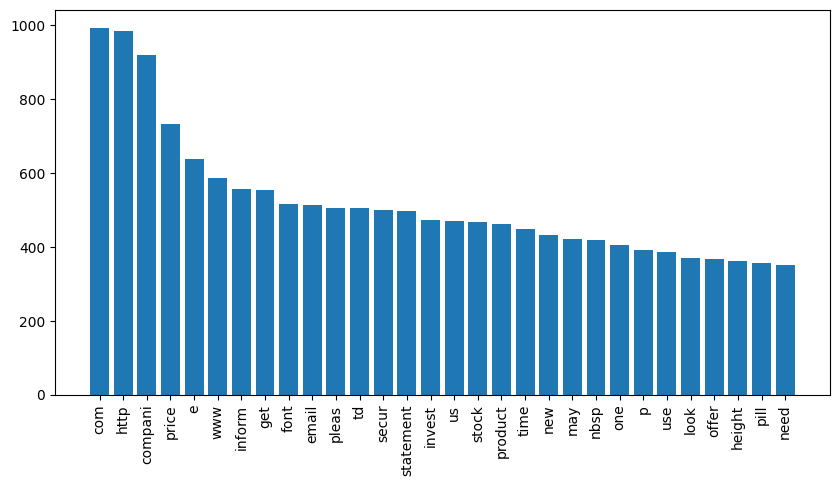

In [58]:
from collections import Counter
data = Counter(spam2).most_common(30)
data = pd.DataFrame(data, columns=['word', 'count'])
plt.figure(figsize=(10, 5))
plt.bar(data['word'], data['count'])
plt.xticks(rotation=90)
plt.show()

[('ect', 13897), ('hou', 7281), ('enron', 6555), ('deal', 3549), ('ga', 2895), ('pleas', 2737), ('subject', 2733), ('meter', 2718), ('com', 2717), ('cc', 2379), ('pm', 2325), ('hpl', 2318), ('thank', 2125), ('daren', 1901), ('need', 1730), ('corp', 1710), ('volum', 1668), ('forward', 1608), ('know', 1458), ('mmbtu', 1408), ('e', 1338), ('j', 1300), ('day', 1292), ('chang', 1242), ('nom', 1185), ('attach', 1169), ('farmer', 1139), ('contract', 1129), ('let', 1104), ('price', 1081)]


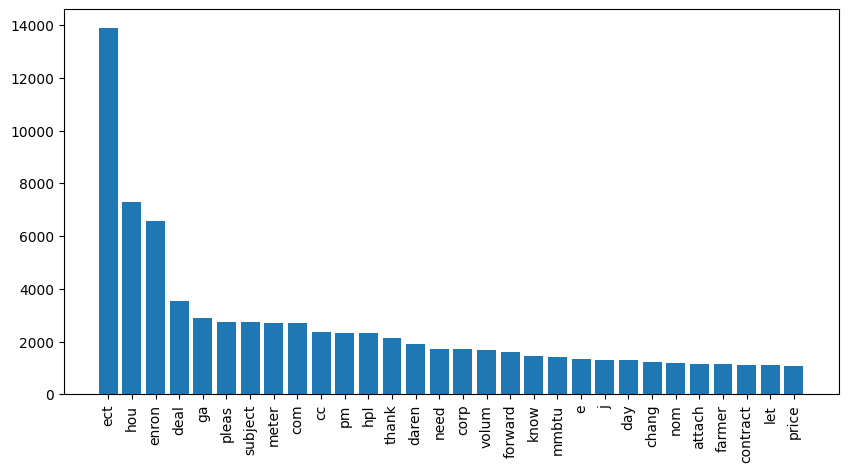

In [59]:
data = Counter(ham2).most_common(30)
print(data)
data = pd.DataFrame(data, columns=['word', 'count'])
plt.figure(figsize=(10, 5))
plt.bar(data['word'], data['count'])
plt.xticks(rotation=90)
plt.show()

In [26]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfdf = TfidfVectorizer(max_features=3000)

x = cv.fit_transform(df['text2'])
print(x.shape)
x = x.toarray()

x1 = tfdf.fit_transform(df['text2']).toarray()
y = df['label_num'].values
print(x, x1, y)

(5171, 42592)
[[1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] [[0.12509994 0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]] [0 0 0 ... 0 0 1]


In [27]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y, test_size=0.2, random_state=42)

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression


In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score


In [30]:
dict = {}
lt = [DecisionTreeClassifier(), KNeighborsClassifier(), MultinomialNB(), BernoulliNB(), GaussianNB(), RandomForestClassifier(), LogisticRegression()]
for model in lt:
  dict[str(model)] = model.fit(x_train, y_train)
  print("Done", str(model))


Done DecisionTreeClassifier()
Done KNeighborsClassifier()
Done MultinomialNB()
Done BernoulliNB()
Done GaussianNB()
Done RandomForestClassifier()
Done LogisticRegression()


In [31]:
dict2 = {}
lt2 = [DecisionTreeClassifier(), KNeighborsClassifier(), MultinomialNB(), BernoulliNB(), GaussianNB(), RandomForestClassifier(), LogisticRegression()]
for model in lt2:
  dict2[str(model)] = model.fit(x1_train, y1_train)
  print("Done", str(model))

Done DecisionTreeClassifier()
Done KNeighborsClassifier()
Done MultinomialNB()
Done BernoulliNB()
Done GaussianNB()
Done RandomForestClassifier()
Done LogisticRegression()


In [32]:
print("Model --------------------Accuracy------------------precicion")
for key,value in dict.items():
  print(key, accuracy_score(value.predict(x_test), y_test)*100, precision_score(value.predict(x_test), y_test)*100)

Model --------------------Accuracy------------------precicion
DecisionTreeClassifier() 93.23671497584542 90.10238907849829
KNeighborsClassifier() 81.35265700483092 96.24573378839591
MultinomialNB() 97.487922705314 96.58703071672356
BernoulliNB() 85.70048309178743 53.92491467576792
GaussianNB() 94.97584541062803 86.3481228668942
RandomForestClassifier() 97.58454106280193 96.58703071672356
LogisticRegression() 97.97101449275362 97.26962457337885


In [33]:
print("Model with tfdf------------------Accuracy------------------precicion")
for key,value in dict2.items():
  print(key, accuracy_score(value.predict(x1_test), y1_test)*100, precision_score(value.predict(x1_test), y1_test)*100)

Model with tfdf------------------Accuracy------------------precicion
DecisionTreeClassifier() 94.4927536231884 89.419795221843
KNeighborsClassifier() 68.5024154589372 100.0
MultinomialNB() 95.26570048309179 93.85665529010238
BernoulliNB() 92.56038647342996 87.37201365187714
GaussianNB() 96.71497584541063 94.88054607508532
RandomForestClassifier() 98.16425120772946 97.61092150170649
LogisticRegression() 98.06763285024155 97.26962457337885


In [34]:
from sklearn.svm import SVC
svc = SVC(kernel='linear')
svc.fit(x_train, y_train)
y_pred = svc.predict(x_test)


In [35]:
dict["svc()"] = svc
print(accuracy_score(y_pred, y_test), precision_score(y_pred, y_test))

0.966183574879227 0.9419795221843004


In [36]:
svc2 = SVC(kernel='linear')
svc2.fit(x1_train, y1_train)
y1_pred = svc2.predict(x1_test)
print(accuracy_score(y1_pred, y1_test), precision_score(y1_pred, y1_test))


0.9855072463768116 0.9795221843003413


In [37]:
dict2["svc()"] = svc2

In [38]:
import pickle
pickle.dump(svc, open('model_svc.pkl', 'wb'))
pickle.dump(tfdf, open('vectorizer.pkl', 'wb'))
#

In [39]:
model_svc = pickle.load(open('model_svc.pkl', 'rb'))
vectorizer = pickle.load(open('vectorizer.pkl', 'rb'))

y1_pred = model.predict(x1_test)
print(accuracy_score(y1_pred, y1_test), precision_score(y1_pred, y1_test))

0.9806763285024155 0.9726962457337884


In [43]:
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier()
sgd.fit(x_train, y_train)
y_pred = sgd.predict(x_test)

sgd2 = SGDClassifier()
sgd2.fit(x1_train, y1_train)
y1_pred = sgd2.predict(x1_test)

In [44]:
print(accuracy_score(y_pred, y_test), precision_score(y_pred, y_test))
print(accuracy_score(y1_pred, y1_test), precision_score(y1_pred, y1_test))

0.9797101449275363 0.9590443686006825
0.9874396135265701 0.9829351535836177


In [60]:
pickle.dump(sgd2, open('model_sgd.pkl', 'wb'))


In [48]:
df.head(5)

,Unnamed: 0,text,label_num,len,text2
0,605,enron methanol ; meter # : 988291\r\nthis is ...,0,2.514548,enron methanol meter 988291 follow note gave m...
1,2349,"hpl nom for january 9 , 2001\r\n( see attache...",0,1.986772,hpl nom januari 9 2001 see attach file hplnol ...
2,3624,"neon retreat\r\nho ho ho , we ' re around to ...",0,3.402089,neon retreat ho ho ho around wonder time year ...
3,4685,"photoshop , windows , office . cheap . main t...",1,2.617000,photoshop window offic cheap main trend abas d...
4,2030,re : indian springs\r\nthis deal is to book t...,0,2.526339,indian spring deal book teco pvr revenu unders...


***FOR RANDOM SAMPLE EXTRACTION FOR TESTING PURPOSE***

In [144]:
df2 = pd.read_csv(os.path.join(path, "spam_ham_dataset.csv"))
df2.head()
df2['text'] = df['text'].apply(lambda x : remove_subject(x))
df2.head()

spam = []
ham = []
for i in range(len(df2)):
    if df['label_num'][i] == 1:
        spam.append(df['text2'][i])
    else:
        ham.append(df['text2'][i])

# spam = [j  for text in spam for j in text.split()]
# ham = [j  for text in ham for j in text.split()]

In [145]:
spam = [spam[j] for j in range(4, 500, 5)]
len(spam)
ham = [ham[j] for j in range(17, 500, 5)]
print(len(spam), len(ham))

100 97


In [159]:
print(df2.sample()['text'])

2982     meet local women\r\nclick here to be removed\r\n
Name: text, dtype: object
